# Diagonalisation exacte

## I. Fonctions 

### a) Récapitulatif des fonctions utilisées

### b) Le code

In [30]:
# import des modules 

import numpy as np # pour les matrices denses 
from sklearn.metrics import r2_score
import scipy.sparse as sp # pour les matrices sparse (creuses)
from scipy.sparse import coo_matrix
import matplotlib.pyplot as plt
from qat.core import Term
from qat.fermion.hamiltonians import FermionHamiltonian
from qat.fermion.hamiltonians import make_anderson_model
from qat.lang import *
from qat.core import Term, Schedule, Variable, Observable
from qat.qpus import get_default_qpu
from qat.plugins import ScipyMinimizePlugin
from qat.lang.AQASM import Program, QRoutine
import numpy.typing as npt
from collections import deque

In [31]:
#Création, annihilation


def matrice_creation(nqbits: int, i: int, spin: str):
    """ Calcule la matrice de l'opérateur c_{i, spin}.
    """
    if spin=="+":
        M = FermionHamiltonian(nqbits, [Term(1., "C", [i])]).to_spin().get_matrix()
        return M
    else:
        M = FermionHamiltonian(nqbits, [Term(1., "C", [i+1])]).to_spin().get_matrix()
        return M

def matrice_annihilation(nqbits: int, i: int, spin: str):
    """ Calcule la matrice de l'opérateur c^{dagger}_{i, spin}.
    """
    if spin=="+":
        M = FermionHamiltonian(nqbits, [Term(1., "c", [i])]).to_spin().get_matrix()
        return M
    else:
        M = FermionHamiltonian(nqbits, [Term(1., "c", [i+1])]).to_spin().get_matrix()
        return M

In [32]:
# définition du Hamiltonien du modèle de Anderson et des opérateurs associés


def couplingOp(n_qubits: int, energy: float, i: int, j: int, spin_i: str, spin_j: str) : 
    """ Calcule une instance de FermionHamiltonian associée à l'opérateur c^{dagger}_{i, sigma1}c_{j, sigma2}, 
    i et j sont les numéros de site, energy est le préfacteur énergétique apparaissant dans 
    la définition du hamiltonien. 
    """
    if spin_i == "+" :
         if spin_j == "-" :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i, j+1])])
         else :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i, j])])
    else :
         if spin_j == "-" :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i+1, j+1])])
         else :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i+1, j])]) 
        
def nOp(n_qubits, energy, i, spin) :
    """ Calcule une instance de FermionHamiltonian associée à l'opérateur n_{i, spin} avec le préfacteur energy.
    """
    return couplingOp(n_qubits, energy, i, i, spin, spin)

def apply_pauli_term(term: dict, coeff: complex, n_qubits: int):
    """Construit les éléments non nuls d’un terme de type PauliString."""
    dim = 2 ** n_qubits
    row, col, data = [], [], []

    for basis_state in range(dim):
        new_state = basis_state
        amp = coeff

        for qubit, pauli in term.items():
            bit = (basis_state >> qubit) & 1
            if pauli == 'X':
                new_state ^= (1 << qubit)
            elif pauli == 'Y':
                new_state ^= (1 << qubit)
                amp *= (1j if bit == 0 else -1j)
            elif pauli == 'Z':
                amp *= (1 if bit == 0 else -1)

        row.append(new_state)
        col.append(basis_state)
        data.append(amp)

    return row, col, data

def build_sparse_from_spinham(spin_ham, n_qubits):
    """Construit la matrice creuse en filtrant rigoureusement les zéros."""
    from scipy.sparse import csc_matrix
    import numpy as np
    
    full_row, full_col, full_data = [], [], []
    ZERO_THRESHOLD = 1e-14  # Seuil pour filtrer les zéros numériques

    for term in spin_ham.terms:
        # Accès aux données du terme via _term
        actual_term = term._term
        coeff = actual_term._coeff.complex_p.re  # Partie réelle du coefficient
        
        if abs(coeff) < ZERO_THRESHOLD:
            continue
            
        # Construction du dictionnaire {qubit: opérateur}
        term_dict = {actual_term.qbits[i]: actual_term.op[i] 
                    for i in range(len(actual_term.qbits))}
        
        # Application du terme Pauli avec filtrage des zéros
        r, c, d = apply_pauli_term(term_dict, coeff, n_qubits)
        
        # Filtrage supplémentaire
        non_zero = [i for i, val in enumerate(d) if abs(val) > ZERO_THRESHOLD]
        full_row.extend(r[i] for i in non_zero)
        full_col.extend(c[i] for i in non_zero)
        full_data.extend(d[i] for i in non_zero)

    # Construction finale de la matrice
    dim = 2 ** n_qubits
    sparse_mat = csc_matrix((full_data, (full_row, full_col)), 
                          shape=(dim, dim),
                          dtype=np.float64)
    
    # Elimination finale des zéros résiduels
    sparse_mat.eliminate_zeros()
    
    return sparse_mat

    
def hamiltonian_ancienne(n_impurities: int, n_bain: int, U: float, mu: float, t: list, V, epsilon: list) :
    """ Calcule le hamiltonien du modèle d'Anderson et le renvoie sous la forme 
    du couple (SpinHamiltonian, matrice associée).

    U : énergie de répulsion coulombienne (positive)

    t : énergies cinétiques de couplage entre impuretés (négatives)

    mu : potentiel chimique (coût énergétique pour rajouter un électron au système ouvert) (négatif)

    V : énergie cinétique d'hybridation (taille n_impurities * n_bain) (négatives)
    
    epsilon : énergies cinétiques de couplage entre électrons du bain (taille n_bain) (négatives)
    """
    n_qubits = 2 * n_bain + 2 * n_impurities
    H_repulsion = 0
    H_hopping = 0
    H_chem = 0
    for wire in range(0, 2*n_impurities, 2) :
        #Calcul du terme de potentiel chimique
        H_chem += nOp(n_qubits, -mu, wire, "+")
        H_chem += nOp(n_qubits, -mu, wire, "-")

        #Calcul du terme d'effet tunnel entre impuretés, dit "hopping"
        for wire2 in range(0, 2*n_impurities, 2) :
            if wire2 != wire :
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "+")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "+")
            else :
                #Calcul du terme de répulsion coulombienne
                H_repulsion += nOp(n_qubits, U, wire, "+")*nOp(n_qubits, 1, wire,"-")
    
    H_impurity_bath = 0
    H_bath = 0
    for wire3 in range(2*n_impurities, n_qubits, 2) :
        i = (wire3 - 2*n_impurities) // 2
        e = epsilon[i]
        #Calcul du terme lié au bain
        H_bath += nOp(n_qubits, e, wire3, "+")
        H_bath += nOp(n_qubits, e, wire3, "-")
        
        for wire4 in range(0, 2*n_impurities, 2) :
            #Calcul du terme d'interaction impureté-bain
            j = wire4 // 2
            v = V[j][i]
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "+", "+") 
            H_impurity_bath += couplingOp(n_qubits, v, wire3, wire4, "+", "+")
            
            v = np.conj(v)
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "-", "-") 
            H_impurity_bath += couplingOp(n_qubits, v, wire3, wire4, "-", "-")
        

    H_anderson = H_repulsion + H_chem + H_impurity_bath + H_bath + H_hopping
    H_spin = H_anderson.to_spin(method = "jordan-wigner")#Fermion to Qubit
    H_sparse = build_sparse_from_spinham(H_spin, n_qubits)
    return H_spin, H_sparse

def hamiltonian(n_impurities: int, n_bain: int, U: float, mu: float, t: float, V, epsilon: list) :
    """ Calcule le hamiltonien du modèle d'Anderson et le renvoie sous la forme 
    du couple (SpinHamiltonian, matrice associée)."""
    n_qubits = 2 * n_bain + 2 * n_impurities
    H_repulsion = 0
    H_hopping = 0
    H_chem = 0
    for wire in range(0, 2*n_impurities, 2) :
        #Calcul du terme de potentiel chimique
        H_chem += nOp(n_qubits, -mu, wire, "+")
        H_chem += nOp(n_qubits, -mu, wire, "-")

        #Calcul du terme d'effet tunnel entre impuretés, dit "hopping"
        for wire2 in range(0, 2*n_impurities, 2) :
            if wire2 != wire :
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "+")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "+")
            else :
                #Calcul du terme de répulsion coulombienne
                H_repulsion += nOp(n_qubits, U, wire, "+")*nOp(n_qubits, 1, wire,"-")
    
    H_impurity_bath = 0
    H_bath = 0
    for wire3 in range(2*n_impurities, n_qubits, 2) :
        i = (wire3 - 2*n_impurities) // 2
        e = epsilon[i]
        #Calcul du terme lié au bain
        H_bath += nOp(n_qubits, e, wire3, "+")
        H_bath += nOp(n_qubits, e, wire3, "-")
        
        for wire4 in range(0, 2*n_impurities, 2) :
            #Calcul du terme d'interaction impureté-bain
            j = wire4 // 2
            v = V[j][i]
            vstar = v if np.isreal(v) else np.conj(v)
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "+", "+") 
            H_impurity_bath += couplingOp(n_qubits, vstar, wire3, wire4, "+", "+")
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "-", "-") 
            H_impurity_bath += couplingOp(n_qubits, vstar, wire3, wire4, "-", "-")
        

    H_anderson = H_repulsion + H_chem + H_impurity_bath + H_bath + H_hopping
    H_spin = H_anderson.to_spin(method = "jordan-wigner")#Fermion to Qubit
    H_sparse = build_sparse_from_spinham(H_spin, n_qubits)
    return H_spin, H_sparse




In [152]:
# algorithme de Lanczos

def lanczos(init: np.ndarray[float], H, m: int, eps: float):
    """ Renvoie la liste des coefficients diagonaux et celle des 
    coefficients sous-diagonaux et surdiagonaux de la matrice de 
    Lanczos 
    
    init : vecteur initial
    
    H : matrice à diagonaliser (préférablement au format csc_array)
    
    m : nombre d'itérations de l'algorithme
    
    eps : seuil d'acceptation
    """
    H = sp.csc_array(H)
    
    a = []
    b = []
    v = init
    V = [init]
    b0 = np.linalg.norm(v)
    b.append(b0)
    v = v/b0  ## Renormalisation, éventuellement dispensable
    w = np.zeros_like(v)
    w += H@v
    a.append((v.T)@w)
    w = w - a[0]*v
    b.append(np.linalg.norm(w))
    for i in range(1,m):
        if b[-1]<eps :
            print("b_i = 0, abort")
            break
        v_new = w/b[-1]  #v_j = w_{j-1} / b_j
        V.append(v_new)
        w = H@v_new
        a.append(v_new.T@w)
        w = w - a[-1]*v_new - b[-1] * v
        v = v_new
        b.append(np.linalg.norm(w))
    V = np.array(V)
    
    return a, b[:-1], V.T

In [153]:
# créer le hamiltonien tridiagonal T

def tridiagonale(diag: np.ndarray[float],sousdiag: np.ndarray[float],surdiag: np.ndarray[float]):
    """ Crée une matrice tridiagionale avec les coefficients correspondants
    """
    return np.diag(diag) + np.diag(sousdiag, k =-1) + np.diag(surdiag, k =1)

In [176]:
# fonction de Green selon la formule de Lehmann

def Green_Lehmann(valeurs_prop: np.ndarray[float], vecteurs_prop: np.ndarray[float], n_site_bain, Omega, eta):
    n_site = n_site_bain + 1
    n_qbits = 2 * n_site
    dim, nb_vp = np.shape(vecteurs_prop)
    
    mat_crea= matrice_creation(n_qbits, 0, "+")
    mat_nihil = matrice_annihilation(n_qbits, 0, "+")
    
    N = len(Omega)
    print(valeurs_prop)
    
    valeurs_prop = valeurs_prop - valeurs_prop[0]
    
    print(valeurs_prop)
    S = []
    for i in range(len(Omega)):
        S_i = 0
        for n in range(nb_vp):
            #Opérateur d'annihilation -> type particule
            prod_scal1 = vecteurs_prop[:,0].T @ mat_nihil @ vecteurs_prop[:,n]
            prod_scal1 = np.real(prod_scal1)**2 + np.imag(prod_scal1)** 2
            
            S_i += ( prod_scal1 ) / (
                         Omega[i] - valeurs_prop[n] + 1j * eta )
            # Opérateur de création -> type trou
            prod_scal2 = vecteurs_prop[:,0].T @ mat_crea @ vecteurs_prop[:,n]
            prod_scal2 = np.real(prod_scal2)**2 + np.imag(prod_scal2)** 2
            
            S_i += ( prod_scal2 ) / (
                       Omega[i] + valeurs_prop[n]  - 1j * eta)
            
            
        S.append(S_i)
    return S

In [177]:
# fonction spectrale selon la formule de Lehmann
def A_Lehman(valeurs_prop: np.ndarray[float], vecteurs_prop: np.ndarray[float], n_site_bain, Omega, eta):
    return - 1 / np.pi * np.imag(Green_Lehmann(valeurs_prop, vecteurs_prop, n_site_bain, Omega, eta)) ## PARTIE IMAGINAIRE
    

In [327]:
# fonction de Green approchée avec l'algorithme de Lanczos

def param_Green(init, H, m, eps):
    """ Calcule l'énergie initiale E_0 et les états initiaux psi_c = cdagger_0 psi_0 et psi_d = c_0 psi_0 pour le calcul de la fonction de Green 
    avec excitation particulaire et excitation lacunaire respectivement"""
    a,b,V = lanczos(init,H,m,eps)
    T = tridiagonale(a,b[1:],b[1:]) # b_0 n'apparaît pas dans la matrice tridiagonale
    
    cdagger_0 = matrice_creation(nqbits, 0, "+")
    c_0 = matrice_annihilation(nqbits, 0, "+")
    
    E_0, Vects = sp.linalg.eigsh(T, which = 'SA', k = 1)
    F = Vects[:,0]
    F = V@F
    return (E_0, cdagger_0@F, c_0@F)
    
def greenLanczos(Omega, Eta, psi_c, psi_d, E_0, H, m, eps):
    """Calcule la fonction de Green approchée par 
    l'algortihme de Lanczos"""
    a_c, b_c, V_c = lanczos(psi_c, H, m, eps)
    a_d, b_d, V_d = lanczos(psi_d, H, m, eps)
    return greenLanczosFrac(Omega  + 1j * Eta + E_0 * np.ones_like(Omega), a_c, b_c)
    - greenLanczosFrac(- Omega + 1j * Eta + E_0 * np.ones_like(Omega), a_d, b_d) 
    
   

def greenLanczosFrac(z: np.ndarray[float], a: np.ndarray[float], b: np.ndarray[float]):
    """Calcule l'image de Z par la transformée de Fourier approchée 
    de la fonction de Green
    """
    frac = np.zeros_like(z)
    n = len(b)
    for i in range(n-1, 0, -1):
        frac = b[i]**2/(z-a[i]-frac)
    return 1/(z-a[0]-frac)

In [328]:
#Fonction spectrale par Lanczsos
def spectraleLanczos(Omega, Eta, psi_c, psi_d, E_0, H, m, eps):
    """ Calcule la fonction spectrale approchée par l'algorithme de Lanczos"""
    return - 1/np.pi * np.imag(greenLanczos(Omega, Eta, psi_c, psi_d, E_0, H, m, eps)) # PARTIE IMAGINAIRE
    

## II. Tests

### a) Convergence de l'algorithme de Lanczos

In [329]:
# Premier vecteur à partir duquel on lance Lanczos

def initialise(n):
    """ Tire les composantes du vecteur initial selon une loi normale centrée réduite, 
    renvoie le vecteur normalisé """
    v = np.random.normal(0,1, n).astype(complex)
    v = v / np.linalg.norm(v)
    return v

In [350]:
#Paramètres physiques
n_impur = 1 
n_bain = 1
nqbits = 2 * (n_impur + n_bain)
N_sys = 4**(n_impur + n_bain)

low_U = 1
high_U = 1
U = np.random.uniform(low_U,high_U) # Coulombian repulsion

low_mu = 1
high_mu= 1
mu = np.random.uniform(low_mu,high_mu) # Chemical potential

low_T = 1
high_T =1
T = np.random.uniform(low_T,high_T) # Hopping between impurities

low_V = 1
high_V =1
V_alea = np.random.uniform(low_V, high_V, (n_impur,n_bain)) # Hybridization energy

low_E = 1
high_E = 1
Eps_alea = np.linspace(low_E, high_E, n_bain)#np.random.uniform(low_E,high_E, n_bain) # Hopping of conduction electrons

def print_param(s, val):
    print (s + " : " + str(val))

Params = [["n_bain", n_bain], ["U", U], ["mu", mu], ["T", T], ["V_alea", V_alea], ["Eps_alea", Eps_alea]]

for param in Params:
    print_param(param[0], param[1])

AndersonHamiltonian, H = hamiltonian(n_impur, n_bain, U, mu, T, V_alea, Eps_alea)


H = AndersonHamiltonian.get_matrix()
H = np.real(H)

eigval1 = np.sort(sp.linalg.eigsh(H)[0])
#eigval2 = np.sort(sp.linalg.eigsh(H2)[0])

print(" Valeurs propres H1 : ", eigval1)
#print(" Valeurs propres H2 : ", eigval2)
#print("Écarts : ", np.abs(eigval1 - eigval2))

#Le même spectre ! Même physique

init = initialise(N_sys)



n_bain : 1
U : 1.0
mu : 1.0
T : 1.0
V_alea : [[1.]]
Eps_alea : [1.]
 Valeurs propres H1 :  [-2.17740968 -1.41421356  1.41421356  1.61803399  1.61803399  2.85577251]


In [351]:
# Fonction de densité
    
def sparsite(H) -> float :
    return (H.count_nonzero() / np.prod(H.shape))


In [352]:
#Test de densité
n_max = 7

def densite(n_max):
    N_bain = list(range(n_max))


    Y = np.zeros(n_max)

    for i in range(len(N_bain)):
    
        low_V = 1
        high_V =1 
        V_alea = np.random.uniform(low_V, high_V, (n_impur,N_bain[i])) # Hybridization energy

        low_E = 1
        high_E = 1
        Eps_alea = np.linspace(-1, 1, N_bain[i])#np.random.uniform(low_E,high_E, n_bain) # Hopping of conduction electrons

        AndersonHamiltonian, H = hamiltonian(n_impur, N_bain[i], U, mu, T, V_alea, Eps_alea)
        Y[i] = sparsite(H)
    Y_log = np.log(Y)

    P = np.polyfit(N_bain, Y_log, deg  = 1, full = True)

    print(P)

    a,b = P[0]
    Y_reg = a * np.ones(n_max) * N_bain + b * np.ones(n_max)

    r2 = r2_score(Y_log, Y_reg)
    print(r"$r^2$" + " score  : " + str(r2))

    return N_bain, Y, Y_log, Y_reg, a, b

#N_bain, Y, Y_log, Y_reg, a, b =densite(n_max)

In [353]:
#Graphiques de densité
def affiche_densité():
    plt.figure()
    plt.scatter(N_bain, Y, color ='b')
    plt.title("Densité des matrices de Anderson")
    plt.xlabel("Sites de bain")
    plt.ylabel("Densité")
    
    plt.figure()
    plt.scatter(N_bain, np.log(Y), color ='b', label = "Densités logarithmiques")
    plt.plot(N_bain, Y_reg, color ='r', label = "Régression linéaire")
    plt.xlabel("Sites de bain")
    plt.ylabel("Densité")
    plt.title("Densité en fonction du nombre de sites de bain")
    plt.legend()
    plt.show()

#affiche_densité()

In [354]:
#Calcul du facteur exponentiel

#print( 4 * np.exp(a))

In [355]:
#Paramètres numériques

psi_0 = initialise(N_sys) #Premier vecteur pour démarrer Lanczos
m = 20
eps_seuil = 10**(-12)

Nous allons contrôler dans un premier temps la convergence de la valeur propre la plus faible.

In [356]:
#Écart à la valeur propre minimale

def ecartVPLower(H, m: int, init: np.ndarray[float], eps: float):
    """ Affiche l'écart absolu entre les valeurs propres théoriques et pratiques 
    les plus faibles.
    """
    ecart = []
    iteration = []
    eigvallow = np.real(sp.linalg.eigs(H,  which = 'SR', k = 1)[0][0])
    for i in range(1,m):
        iteration.append(i)
        a, b, V = lanczos(init, H, m, eps)
        T = tridiagonale(a, b[1:], b[1:])
        ecart.append(abs(np.linalg.eigvalsh(T)[0]-eigvallow))
    plt.figure()
    plt.plot(iteration, ecart, label = "écart absolu")
    plt.title("Convergence de la valeur propre la plus faible via l'algorithme de Lanczos")
    plt.xlabel("Itération")
    plt.ylabel("Écart absolu entre la valeur propre théorique la plus faible et celle obtenue par l'algorithme")
    plt.show()
    return

In [357]:
#ecartVPLower(H, 30, init, 10**(-10))

In [358]:
#Test par diagonalisation

def vraies_vp(H, k_eig, which_eig, ndecimales):
    S = np.sort(np.real(sp.linalg.eigsh(H, which = which_eig, k = k_eig)[0]))

    if ndecimales == 0:
        return S
    else:
        return np.unique(np.round(S,ndecimales))

def vp_lanczos(H, m, init, eps, k_eig, which_eig, ndecimales):
    a, b, V = lanczos(init, H, m, eps)
    Trid = tridiagonale(a, b[1:], b[1:])
    
    return vraies_vp(Trid, k_eig, which_eig, ndecimales)

def shorten(L,eig_inf: bool):
    lengths = [len(l) for l in L]
    nvals = np.min(lengths)
    if eig_inf:
        for l in L:
            l = l[:nvals]
    else:
        for i in range(len(L)):
            l = l[lengths[lengths[i] - nvals:]]
    return nvals

def ecartsVP(H, m, init: np.ndarray[float], eps: float, k_inf, k_sup, affiche, ndecimales = 0, couleurs = plt.get_cmap('tab10').colors):
    """ Caclcule l'écart absolu entre les k_inf valeurs propres théoriques et pratiques les plus petities et les k_sup plus grandes.
        Les affiche si affiche vaut True.
        Le fait pour des valeurs propres unique avec une précison de ndecimales si ndecimales > 0
    """

    def ecarts(k_eig: int, eig_inf: bool):

        if eig_inf:
            which_eig = 'SA'
            adj_eig = "inférieures"
            adj_ecarts = "inférieurs"
            adj_rang = "inférieur"
            
        else:
            which_eig = 'LA'
            adj_eig = "supérieures"
            adj_ecarts = "supérieurs"
            adj_rang = "supérieur"
        
        eigvals = []
        
        if k_eig > 0:
            eigval_true =  vraies_vp(H, k_eig, which_eig, ndecimales)
            
            eigvals.append(vp_lanczos(H, M[0], init, eps, k_eig, which_eig, ndecimales))
            
            n_vals = min(len(eigvals[0]),len(eigval_true))

            if eig_inf:

                eigval_true = eigval_true[:n_vals]
                eigvals[0] = eigvals[0][:n_vals]
            
                for i in range(1,len(M)):  
                    eigvals.append(vp_lanczos(H, M[i], init, eps, k_eig, which_eig, ndecimales))
                    eigvals[i] = eigvals[i][:n_vals]
                    #print(len(eigvals[i]))
            else:
                eigval_true = eigval_true[len(eigval_true)-n_vals:]
                eigvals[0] = eigvals[0][len(eigvals[0])-n_vals:]
            
                for i in range(1,len(M)):  
                    eigvals.append(vp_lanczos(H, M[i], init, eps, k_eig, which_eig, ndecimales))
                    eigvals[i] = eigvals[i][len(eigvals[i])-n_vals:]
                    #print(len(eigvals[i]))


            eigvals_true = np.array([eigval_true for i in range(len(M))])
                
            ecarts = np.abs(eigvals- eigvals_true)
        
            if affiche:
                print("Valeurs " + adj_eig + " approximées : " + str(eigvals) +"\n", 
                      "Vraies valeurs " + adj_eig + " : " + str(eigvals_true) +"\n", 
                      "Écarts " + adj_ecarts + " : " + str(ecarts) + "\n", "Erreur : "
                      + str(np.linalg.norm(ecarts)))
                print("\n")
                
        
            plt.figure()

            X = list(range(n_vals))

            print(len(ecarts))

            
            for i in range(len(M)):
                plt.scatter(X, ecarts[i], color = couleurs[i], label = r"$m$ = " + str(M[i]))
            plt.title("Convergence des valeurs propres " + adj_eig + " via l'algorithme de Lanczos ")
            plt.xlabel("Rang " + adj_rang + " de la valeur propre")
            plt.ylabel("Écart")
            plt.legend()
            plt.show()
        return
        
    ecarts(k_inf, True)
    ecarts(k_sup, False)
    
    return

    




In [359]:
#Convergence des valeurs propres
M = np.arange(10,50,5)

#ecartsVP(H, M, init, 10**(-10), 16, 16, False, ndecimales = 3)

Nous comparons à chaque itération la nouvelle valeur de b calculée à epsilon, mais est-ce que b converge ?

In [360]:
def affichage(H, m: int, init: np.ndarray[float], eps: float):
    a, b, V = lanczos(init, H, m, eps)
    plt.figure()
    plt.plot(b, label = "Évolution du paramètre b")
    plt.xlabel("Itération")
    plt.ylabel("Grandeur b")
    plt.show()
    return

In [361]:
#affichage(H, 70, init, 10**(-10))

### b) Comparaison des fonctions de Green de Lehmann et celle approchée par Lanczos

In [362]:
# affichage de la fonction de Green
def plot_spectrales(inf : float, sup : float, n_vals : int, eta : float, n_site_bain : int, E_0 : float, psi_c, psi_d):
    n_sites = 1 + n_site_bain 
    n_qbits = 2 * n_sites
    valeurs_prop, vecteurs_prop = sp.linalg.eigsh(H)
    Omega = np.linspace(inf,sup, n_vals)
    Eta = eta * np.ones_like(Omega)
    
    Y1 = spectraleLanczos(Omega, Eta, psi_c, psi_d, E_0, H, m, eps_seuil)
    
    
    
    
    Y2 = A_Lehman(valeurs_prop, vecteurs_prop, n_site_bain, Omega, eta)

    plt.figure()
    plt.title("Spectre approché de la fonction de Green")
    plt.xlabel(r"$\omega$")
    plt.ylabel(r"$A(\omega + i \eta)$")
    plt.plot(Omega,Y1, color = 'r', label = "Spectre approché, valeur abs")
    plt.plot(Omega, Y2, color = 'b', label = "Spectre exact")
    plt.legend()
    
    plt.show()
    return

In [363]:
#Paramètres du tracé de la fonction de Green

omega_inf = -50
omega_sup = 50
n_vals = 1001
eta = 0.01


In [364]:
init = initialise(N_sys)

In [370]:
E_0, psi_c, psi_d = param_Green(init, H, m, eps_seuil)

b_i = 0, abort


[-2.17740968 -1.41421356  1.41421356  1.61803399  1.61803399  2.85577251]
[0.         0.76319612 3.59162324 3.79544367 3.79544367 5.03318219]


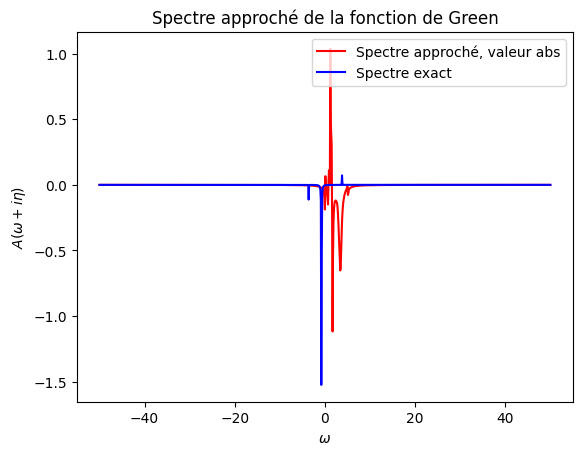

In [371]:
plot_spectrales(omega_inf,omega_sup,n_vals,eta, n_bain, E_0, psi_c, psi_d)

In [347]:
def plot_spectrales_amas(n_vals : int, H, init, m, eps_seuil) :
    valeurs_prop, vecteurs_prop = sp.linalg.eigsh(H)
    
    a, b, V = lanczos(init, H, m, eps_seuil)
    T = tridiagonale(a, b[1:], b[1:])
    valeurs_prop, vecteurs_prop = sp.linalg.eigsh(T, k = n_vals)
    E_0 = valeurs_prop[0]
    F = V@vecteurs_prop[:,0]
    y = []
    y_trous = []
    E_0_vect = np.full(n_vals, E_0)
    x = valeurs_prop - E_0_vect # array avec l'emplacement des diracs
    x_trous = E_0_vect - valeurs_prop
    psi_n = V@vecteurs_prop # array des vecteurs propres approchés
    for i in range(len(valeurs_prop)):
        y.append(psi_c@(psi_n[:,i])) # valeur correspondant à l'intensité du dirac
        y_trous.append(psi_n[:,i])
    
    # à prendre avec des pincettes : la double somme a été oubliée, on ne se concentre que sur les électrons, et pas sur les trous
    # comment ajouter cette subtilité ? 
    # cela fonctionne-t-il déjà ? 
    affichage_amas(x,y)
    return affichage_amas(x_trous,y_trous) # il faudra superposer les deux graphes, pour l'instant laisser ainsi 
    #pour mieux comprendre ce qu'il se passe

# fonction pour afficher le spectre 
# l'entrée x est un array correspondant aux emplacements des diracs
# l'entrée y[i] est un float quantifiant l'intensité du dirac 

def affichage_amas(x,y): 
    plt.figure()
    X = []
    Y = []
    for i in range (len(x)-1):
        Y.append(y[i])
        Y.append(0)
        Y.append(0)
        X.append(x[i])
        X.append(x[i])
        X.append(x[i+1])
    Y.append(y[-1])
    X.append(x[-1])
    plt.plot(X,Y)
    plt.xlabel("omega")
    plt.ylabel("intensité de la fonction spectrale")
    
    plt.show()
    return 

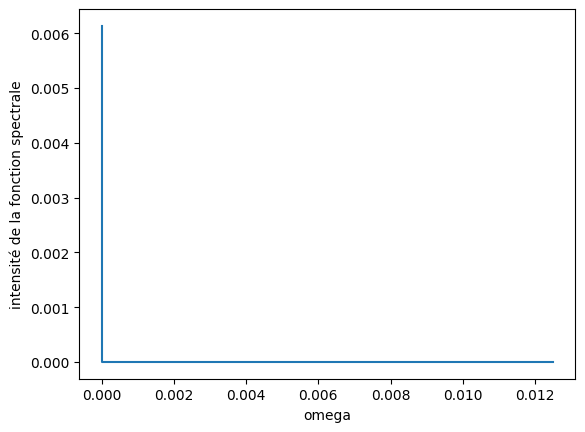

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (7,) + inhomogeneous part.

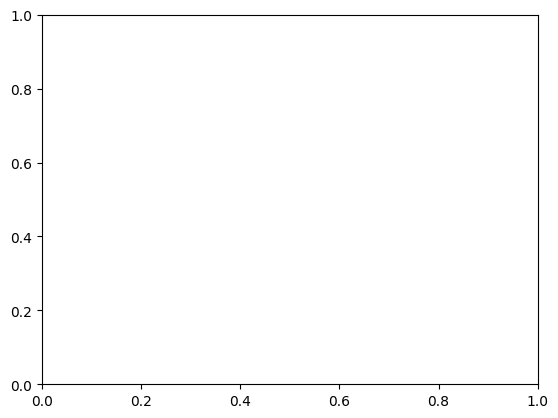

In [348]:
x = [0,1, 2]
y = [10,30,15]
plot_spectrales_amas(3, H, init, m, eps_seuil)

## III. Théorie

## Algorithme de Lanczos

Cet algorithme prend une matrice représentant le hamiltonien de Anderson $H$ en entrée, de taille $n \times n$.
Soit $v_1$ un vecteur unitaire de l'espace de Hilbert de dimension $n$.

On note, pour $m$ quelconque, l'espace de Kyrllov associé à $v_1$ $$\mathcal{K}_m  = \text{Vect } (v_1, Hv_1, \dots, H^{m-1} v_1)$$
L'objectif de cet algorithme est de construire une matrice $V$ de taille $n \times m$ qui représente une base orthonormale $(v_1, \dots, v_m)$ de l'espace de Kyrllov de dimension $m$ associé à $H$, ainsi qu'une matrice tridiagonale symétrique $T$ de taille $m \times m$  représentant la restriction de $H$ à $K_m$ : 

$$ T = V^{*}HV$$

On note $$T = 
\begin{pmatrix} 
\alpha_1 & \beta_1     &              &             &              &0        \\
\beta_1  & \alpha_2    & \beta_2      &             &              &          \\
         & \beta_2     &  \alpha_3    & \ddots      &              &           \\
         &             &  \ddots      & \ddots      & \beta_{m-2}  &            \\
         &             &              & \beta_{m-2} & \alpha_{m-1} & \beta_{m-1} \\
0        &             &              &             & \beta_{m-1}  & \alpha_{m}
\end{pmatrix}
$$

L'algorithme procède par une orthonormalisation de Gram-Schimdt qui exploite le caractère hermitien de $H$ : de nombreux coefficients correctifs sont en pratique nuls.


#### Calculs effectués :

Initialisation : 

1. $ w'_1 = Hv_1$ 
2. $ \alpha_1 = w'_1 v_1$
3. $w_1 = w'_1 - \alpha_1 v_1$

Boucle itérative :

Pour $j$ allant de $1$ à $m-1$ :
1. $\beta_{j+1} = ||w_{j}||$
2. Si $\beta_{j+1} = 0$, alors chosir un nouveau vecteur $v_{j+1}$ orthogonal aux précédents.
(Tel que dans le papier que nous utilisons, non implémenté, l'algorithme s'arrête dans ce cas)
3. Sinon $v_{j+1} = w_{j} / b_{j+1} $
4. $w'_{j+1} = H v_{j+1}$
5. $\alpha_{j+1} = v_{j+1}^* w'_{j+1}$
6. $w_{j+1} = w'_{j+1} - \alpha_{j+1} v_{j+1} - \beta_{j+1} v_j $
Fin

De sorte que $w'_j = H v_j = \beta_{j+1} v_{j+1} + \alpha_{j} v_j + \beta_{j-1} v_{j-1}$, ce qui définit bien une matrice tridiagonale.

## Fonction de Green

L'avantage particulier de l'algorithme de Lanczos pour le modèle de Anderson  est qu'il permet de déterminer une valeur approchée de la transformée de Fourier de la fonction de Green. 

On a le résultat \begin{align}
  G(z)&=\langle \psi \lvert \frac{1}{z-H}\lvert \psi \rangle \\
   &=  \frac{\langle \psi \lvert \psi \rangle}{z-\alpha_0-\frac{\beta_1^2}{z-\alpha_1-\frac{\beta_2^2}{z-\alpha_2-\frac{\beta_3^2}{...}}}}
   &=  \frac{1}{z-\alpha_0-\frac{\beta_1^2}{z-\alpha_1-\frac{\beta_2^2}{z-\alpha_2-\frac{\beta_3^2}{...}}}}
\end{align}

où $z$ est un nombre complexe.

En reprenant les coefficients $\alpha_i$ et $\beta_i$ précédement calculés :

## Instabilité numérique

Les calculs présentés ci-dessus, dès lors qu'ils sont approchés trop grossièrement, entraînent une perte d'orthonormalité de la base $(v_1, \dots, v_m)$. Des valeurs propres erronées s'introduisent dans le spectre de $T$. Des méthodes possibles de mitigation de ces erreurs font notamment intervenir des conditions d'arrêt additionnelles dans la boucle for présentée plus haut, mais nous ne les avons pas implémentées.

Voici une liste d'améliorations possibles :

1. Empêcher la perte d'orthogonalité
2. Restaurer l'orthogonalité de la base à la fin de l'algorithme
3. Retirer les valeurs propres erronées
4. Tirer les vecteurs initiaux selon une loi normale pour éviter de passer à côté de certains vecteurs propres
5. Diagonaliser avec des méthodes plus efficaces pour les matrices tridiagonales

La piste 5 concerne le problème de diagonalisation dont nous n'aurons pas forcément l'usage, puisque seuls les coefficients de $T$ importent pour le calcul de la fonction de Green.


### Calcul de la fonction de Green

1. Nous avons besoin dans un premier temps de déterminer l'énergie fondamentale $E_0$ du hamiltonien et le vecteur propre $\ket{F}$ qui lui est associé. On choisit un vecteur $\ket{\psi_0}$ vecteur gaussien et l'on fait tourner une première fois l'algorithme de Lanczos.

2. Ce dernier nous renvoie 3 listes, les deux premières servent à construire le hamiltonien projeté sur l'espace de Krylov, matrice tridiagonale $T$. La troisième liste est la matrice $V$ de changement de base. La diagonalisation de l'hamiltonien tridiagonal nous permet d'avoir accès à la valeur propre $\hat{E_0}$ de $T$, très bonne approximation de la valeur propre $E_0$ de $H$, et également au vecteur propre $\ket{\hat{F}}$ associé à la valeur propre $\hat{E_0}$. On a enfin l'approximation $\ket{F}=V\ket{\hat{F}}$

3. On pose $\ket{\psi_c}=c_0^\dagger \ket{F}$ et l'on refait tourner l'algorithme de Lanczos avec comme vecteur initial $\ket{\psi_0}$. Le programme renvoie 2 listes : $(a_0,...,a_L)$ et $(b_1,...,b_L)$. 

4. La fonction de Green approchée vaut $\tilde{G_0}(z)=\bra{F}\frac{1}{z-T-E_0}\ket{F}=[(z-E_0-T)^{-1}]_{00}=\frac{1}{z-E_0-a_0-\frac{b_1^2}{...}}$. Ainsi en utilisant les deux listes précédentes, nous pouvons calculer la fonction de Green approchée sous forme de fraction continue. 


### Vérification expérimentale de la fonction de Green en fraction continue 

Nous décidons de créer une autre fonction spectrale, appelée ici plot_spectrale_amas, qui va tracer la fonction spectrale d'une manière bien précise. Cette fonction n'utilise pas le calcul en fraction continue de la fonction de Green. Nous déterminons les pôles de la fonction de Green grâce aux énergies calculées par algorithme de Lanczos. Puis, nous déterminons l'intensité spectrale liée à ce pic. $\{E_m \}$ est la famille des valeurs propres, et la valeur propre $E_m$ est reliée à l'état propre $\ket{\psi_m}$.

Pour les électrons de bains, on trouve les pics en $\omega = E_m - E_0$

Pour les électrons de trous, on retrouve les pics en $\omega = E_0 - E_{m'}$

Enfin, l'intensité spectrale, que l'on représentera schématiquement par la hauteur du Dirac, vaut pour le bain : $\left| \bra{F} c_0 \ket{\psi _m} \right|^2$ et $\left| \bra{F} c_0^\dagger \ket{\psi _{m'}} \right|^2$ pour les trous.